# Automatic topic tags: do the groups match real subjects?

QuizBank groups a course's questions into topics without any labels, and names each
group by its most distinctive words. Topic modeling is easy to make look good and hard
to measure, so this notebook measures it on questions whose **true subject is known**.

**Data.** The MMLU test set (Hendrycks et al., 2021; MIT license): 14,042 multiple-choice
questions labeled with one of 57 subjects. Each trial picks 10 subjects at random and
100 questions from each, then asks each method to group the 1,000 questions blind.
Three trials with different subjects.

**Methods compared.**
- **TF-IDF + k-means:** cluster word-count vectors (a classic baseline).
- **LDA:** the classic topic model; each question goes to its most likely topic.
- **MiniLM + k-means:** cluster sentence embeddings (QuizBank's method).
- **MiniLM + HDBSCAN:** density-based clustering of the same embeddings.

**Metrics.** Normalized mutual information (NMI) and adjusted Rand index (ARI) between
the groups and the true subjects: 1 is a perfect match, 0 is chance. The k-means methods
and LDA are given the true number of topics (10); separately, we check how well
QuizBank's automatic choice of k (by silhouette score) finds it.

In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from bank.ml import datasets, topics
from bank.ml.embeddings import embed

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)
SURFACE, INK, INK_2, GRID, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#b9b8b3"
BLUE = "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
pd.set_option("display.precision", 3)

mmlu = datasets.load_mmlu(Path.cwd().parent / "data")
counts = mmlu.subject.value_counts()
eligible = sorted(counts[counts >= 100].index)
print(f"{len(mmlu):,} questions, {mmlu.subject.nunique()} subjects; {len(eligible)} subjects have 100+ questions")

14,042 questions, 57 subjects; 57 subjects have 100+ questions


In [2]:
def trial(seed, k=10, per_subject=100):
    rng = np.random.default_rng(seed)
    subjects = sorted(rng.choice(eligible, k, replace=False))
    sample = (mmlu[mmlu.subject.isin(subjects)]
              .groupby("subject").sample(per_subject, random_state=seed).reset_index(drop=True))
    texts, truth = sample.question.tolist(), sample.subject.to_numpy()
    vectors = embed(texts)
    results = {
        "TF-IDF + k-means": topics.tfidf_kmeans(texts, k, seed),
        "LDA": topics.lda(texts, k, seed),
        "MiniLM + k-means": topics.kmeans(vectors, k, seed),
        "MiniLM + HDBSCAN": topics.hdbscan(vectors, min_cluster_size=15),
    }
    auto = topics.find_topics(texts, vectors, k_max=20, seed=seed)
    results["MiniLM + k-means, k chosen automatically"] = auto.labels
    rows = [{"trial": seed, "method": name, "clusters": len(set(labels)),
             "NMI": normalized_mutual_info_score(truth, labels), "ARI": adjusted_rand_score(truth, labels)}
            for name, labels in results.items()]
    return rows, sample, truth, auto

rows, runs = [], {}
for seed in (0, 1, 2):
    trial_rows, sample, truth, auto = trial(seed)
    rows += trial_rows
    runs[seed] = (sample, truth, auto)
scores = pd.DataFrame(rows)
scores.groupby("method", sort=False)[["NMI", "ARI", "clusters"]].agg(["mean", "std"])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/Users/reecemilligan/Desktop/resume/Projects for resume/quizbank-ai/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


/Users/reecemilligan/Desktop/resume/Projects for resume/quizbank-ai/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


/Users/reecemilligan/Desktop/resume/Projects for resume/quizbank-ai/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


NMI           ARI        clusters  \
                                           mean    std   mean    std     mean   
method                                                                          
TF-IDF + k-means                          0.340  0.051  0.122  0.013   10.000   
LDA                                       0.133  0.053  0.081  0.050   10.000   
MiniLM + k-means                          0.751  0.029  0.670  0.058   10.000   
MiniLM + HDBSCAN                          0.185  0.106  0.046  0.037    3.333   
MiniLM + k-means, k chosen automatically  0.741  0.041  0.651  0.082   11.667   

                                                 
                                            std  
method                                           
TF-IDF + k-means                          0.000  
LDA                                       0.000  
MiniLM + k-means                          0.000  
MiniLM + HDBSCAN                          0.577  
MiniLM + k-means, k chosen automatically  2.887

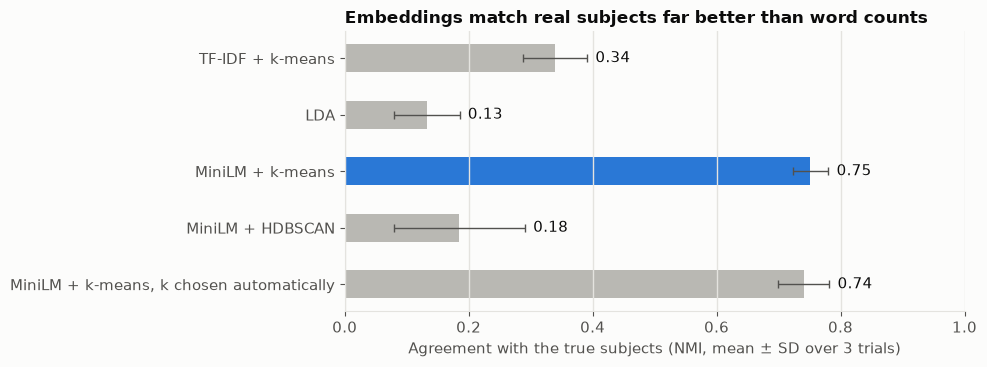

In [3]:
summary = scores.groupby("method", sort=False)["NMI"].agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(10, 3.8))
y = np.arange(len(summary))[::-1]
colors = [BLUE if name == "MiniLM + k-means" else MUTED for name in summary.index]
ax.barh(y, summary["mean"], height=0.5, color=colors, xerr=summary["std"],
        error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 3})
for yi, value, spread in zip(y, summary["mean"], summary["std"]):
    ax.annotate(f"{value:.2f}", (value + spread, yi), xytext=(6, 0), textcoords="offset points", va="center")
ax.set_yticks(y, summary.index)
ax.set_xlim(0, 1)
ax.set_xlabel("Agreement with the true subjects (NMI, mean ± SD over 3 trials)")
ax.grid(axis="y", visible=False)
ax.set_title("Embeddings match real subjects far better than word counts")
fig.tight_layout()
fig.savefig(FIGURES / "03_method_comparison.png", dpi=150)

In [4]:
noise = pd.DataFrame([{"trial": seed,
                       "HDBSCAN clusters": len(set(labels) - {-1}),
                       "questions left as noise": float(np.mean(labels == -1))}
                      for seed in runs
                      for labels in [topics.hdbscan(embed(runs[seed][0].question.tolist()), 15)]])
noise

/Users/reecemilligan/Desktop/resume/Projects for resume/quizbank-ai/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


/Users/reecemilligan/Desktop/resume/Projects for resume/quizbank-ai/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


/Users/reecemilligan/Desktop/resume/Projects for resume/quizbank-ai/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,trial,HDBSCAN clusters,questions left as noise
0,0,2,0.747
1,1,2,0.842
2,2,3,0.632


## Choosing the number of topics

In the app nobody knows the right number of topics, so QuizBank picks k by silhouette
score (how much closer each question is to its own group than to the next one). Here
the truth is 10.

In [5]:
chosen = pd.DataFrame([{"trial": seed, "k chosen": runs[seed][2].k,
                        "best silhouette": max(runs[seed][2].silhouettes.values())} for seed in runs])
chosen

,trial,k chosen,best silhouette
0,0,15,0.115
1,1,10,0.102
2,2,10,0.163


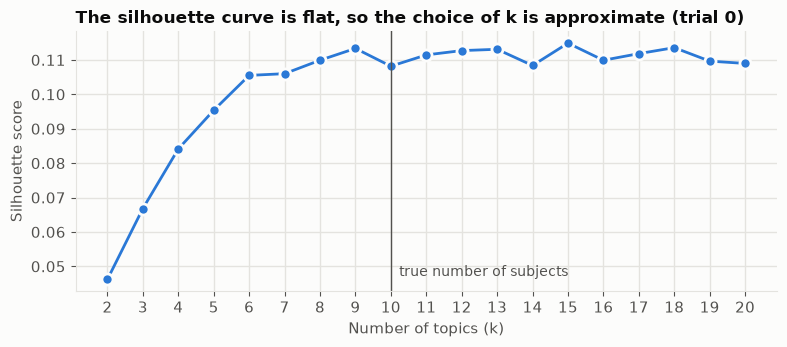

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.6))
sil = runs[0][2].silhouettes
ax.plot(list(sil), list(sil.values()), color=BLUE, linewidth=2, marker="o", markersize=8,
        markeredgecolor=SURFACE, markeredgewidth=2)
ax.axvline(10, color=INK_2, linewidth=1)
ax.annotate("true number of subjects", (10, min(sil.values())), xytext=(6, 0), textcoords="offset points",
            color=INK_2, fontsize=10, va="bottom")
ax.set_xlabel("Number of topics (k)")
ax.set_ylabel("Silhouette score")
ax.set_xticks(list(sil))
ax.set_title("The silhouette curve is flat, so the choice of k is approximate (trial 0)")
fig.tight_layout()
fig.savefig(FIGURES / "03_choosing_k.png", dpi=150)

## Do the names make sense?

Each automatic topic's top three words next to the true subject most of its questions
come from, and how pure the topic is (the share of its questions from that subject).

In [7]:
sample, truth, auto = runs[0]
rows = []
for index, words in auto.keywords.items():
    members = truth[auto.labels == index]
    subject, count = Counter(members).most_common(1)[0]
    rows.append({"topic name": " · ".join(words), "questions": len(members),
                 "mostly from": subject.replace("_", " "), "purity": count / len(members)})
names = pd.DataFrame(rows).sort_values("questions", ascending=False).reset_index(drop=True)
names

,topic name,questions,mostly from,purity
0,indians · gold · silver,101,prehistory,0.802
1,inheritance · mutation · dna,96,medical genetics,0.792
2,earth · mars · solar,95,astronomy,0.979
3,information · king · shall,86,high school world history,0.930
4,atp · energy · exercise,85,college medicine,0.565
5,patient · muscle · complication,83,clinical knowledge,0.711
6,model · variables · iii,75,econometrics,0.987
7,number · nearest · sum,73,high school mathematics,0.808
8,sauna · body · percent,65,econometrics,0.385
9,group · subgroup · order,62,abstract algebra,0.984


In [8]:
purity = pd.concat([
    pd.DataFrame({"trial": seed, "purity": [Counter(runs[seed][1][runs[seed][2].labels == i]).most_common(1)[0][1]
                                                / (runs[seed][2].labels == i).sum() for i in runs[seed][2].keywords]})
    for seed in runs])
print(f"Median topic purity across trials: {purity.purity.median():.0%}; "
      f"topics at least 70% one subject: {(purity.purity >= 0.7).mean():.0%}")

Median topic purity across trials: 91%; topics at least 70% one subject: 86%


In [9]:
worst = names.loc[names.purity.idxmin()]
members = truth[auto.labels == next(i for i, w in auto.keywords.items() if " · ".join(w) == worst["topic name"])]
print(f"Least pure topic: '{worst['topic name']}' ({worst.purity:.0%} one subject), made of:")
Counter(s.replace("_", " ") for s in members).most_common()

Least pure topic: 'sauna · body · percent' (38% one subject), made of:


[('econometrics', 25),
 ('college medicine', 15),
 ('clinical knowledge', 6),
 ('medical genetics', 5),
 ('prehistory', 5),
 ('astronomy', 3),
 ('high school world history', 3),
 ('formal logic', 2),
 ('abstract algebra', 1)]

## Conclusions

- **Embeddings are what make this work.** Clustering MiniLM sentence embeddings matched
  the true subjects with NMI 0.75 (ARI 0.67), against 0.34 for TF-IDF word counts and 0.13
  for LDA. Quiz questions are short, so they share few exact words even within a subject;
  embeddings capture that "mitochondria" and "ATP" belong together.
- **Density-based clustering (HDBSCAN) failed here.** It found only two or three dense
  groups and left 63-84% of the questions as noise, fitting no group, which scores 0.19.
  k-means' "every question gets a topic" suits a filter in a question bank better.
- **Choosing k automatically costs little.** Picking k by silhouette score found the true
  10 in two of three trials (15 in the other) and scored 0.74 versus 0.75 when told the
  true k. The silhouette curve is flat, so k is approximate: topics can split one subject
  in two (formal logic became three topics in trial 0).
- **The names are usually recognizable.** The median topic is 91% one subject, and 86%
  of topics are at least 70% one subject. The exception is a catch-all: in trial 0,
  "sauna · body · percent" (39% one subject) collected leftover questions from nine
  subjects, and its name means little. Every run will have a few like it.
- **The app uses MiniLM + k-means with k chosen by silhouette,** as measured here.